In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/layoffs_cleaned.csv")

df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added,year,month,month_name,quarter
0,SentinelOne,SF Bay Area,230.0,2026-05-29,0.08,Security,https://www.calcalistech.com/ctechnews/article...,Post-IPO,696.0,United States,2026-05-29,2026,5,May,2
1,Rapyd,"Tel Aviv, Non-U.S.",NaN,2026-05-28,NaN,Finance,https://www.calcalistech.com/ctechnews/article...,Unknown,770.0,Israel,2026-05-28,2026,5,May,2
2,NetApp,SF Bay Area,77.0,2026-05-27,NaN,Data,https://hoodline.com/2026/05/san-jose-mainstay...,Post-IPO,NaN,United States,2026-05-28,2026,5,May,2
3,Lightricks,"Jerusalem, Non-U.S.",NaN,2026-05-27,NaN,Consumer,https://en.globes.co.il/en/article-lightricks-...,Series D,335.0,Israel,2026-05-28,2026,5,May,2
4,Webflow,SF Bay Area,NaN,2026-05-27,NaN,Marketing,https://webflow.com/blog/evolving-webflow-for-...,Series C,335.0,United States,2026-05-27,2026,5,May,2


# Question 1
## How have global layoff trends evolved from 2020–2026?

In [3]:
year_summary = pd.DataFrame({
    "Layoff_Events": df.groupby("year").size(),
    "Employees_Laid_Off": df.groupby("year")["total_laid_off"].sum()
})

year_summary

,Layoff_Events,Employees_Laid_Off
year,,
2020,635,80998.0
2021,44,15823.0
2022,1230,165269.0
2023,1387,264320.0
2024,633,152922.0
2025,331,124636.0
2026,168,116137.0


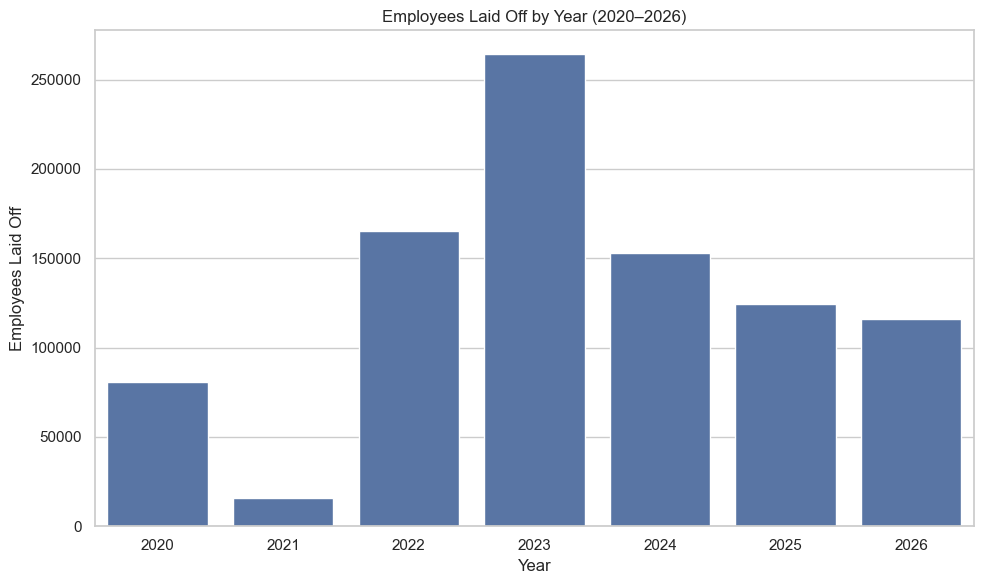

In [4]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=year_summary.reset_index(),
    x="year",
    y="Employees_Laid_Off"
)

plt.title("Employees Laid Off by Year (2020–2026)")
plt.xlabel("Year")
plt.ylabel("Employees Laid Off")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/chart1_layoffs_by_year.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

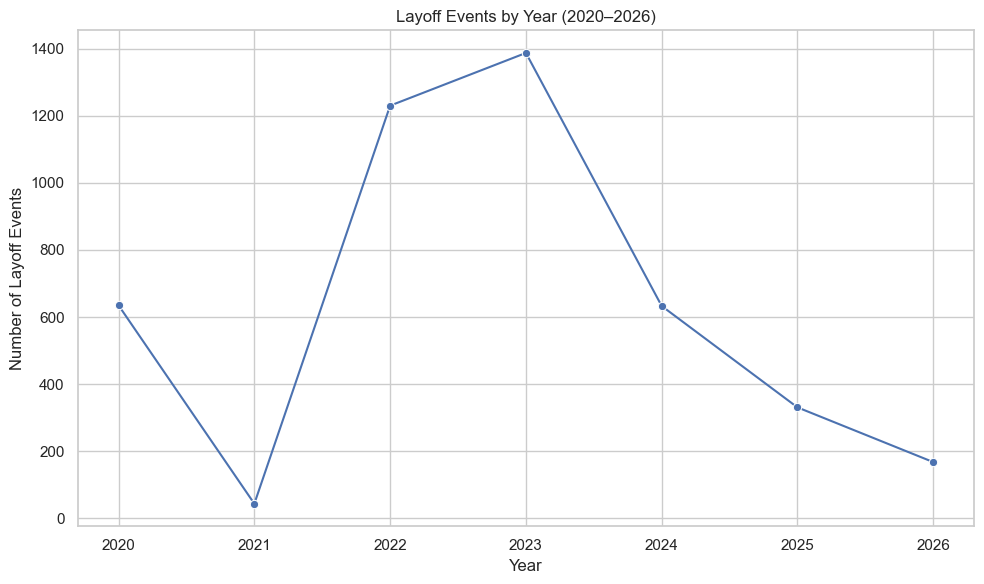

In [5]:
events_by_year = (
    df.groupby("year")
      .size()
      .reset_index(name="Layoff_Events")
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=events_by_year,
    x="year",
    y="Layoff_Events",
    marker="o"
)

plt.title("Layoff Events by Year (2020–2026)")
plt.xlabel("Year")
plt.ylabel("Number of Layoff Events")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/chart2_layoff_events_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Question 2
## Which industries experienced the highest layoff activity and workforce reductions?

In [7]:
industry_layoffs = (
    df.groupby("industry")["total_laid_off"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

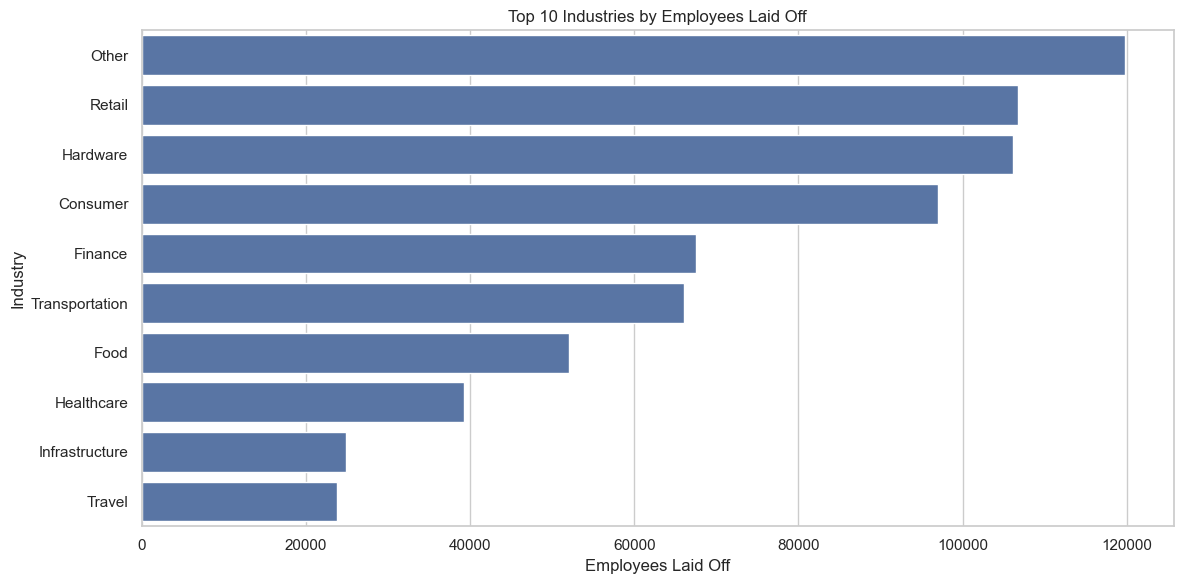

In [8]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=industry_layoffs,
    x="total_laid_off",
    y="industry"
)

plt.title("Top 10 Industries by Employees Laid Off")
plt.xlabel("Employees Laid Off")
plt.ylabel("Industry")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/chart3_top_industries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
industry_avg = (
    df.groupby("industry")["total_laid_off"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

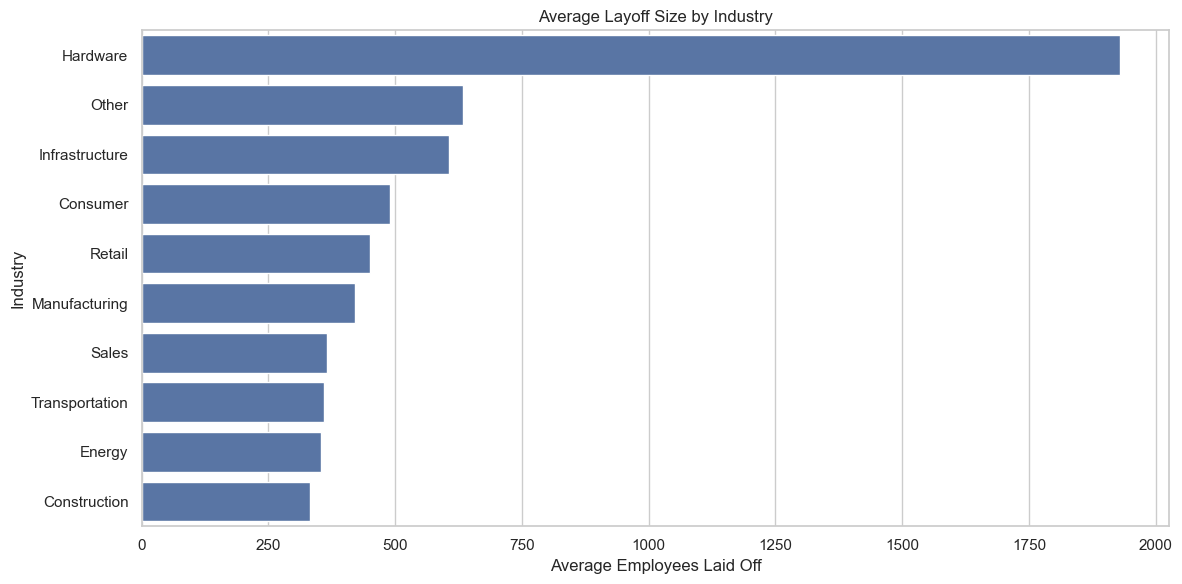

In [10]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=industry_avg,
    x="total_laid_off",
    y="industry"
)

plt.title("Average Layoff Size by Industry")
plt.xlabel("Average Employees Laid Off")
plt.ylabel("Industry")

plt.tight_layout()
plt.savefig(
    "../outputs/charts/chart4_avg_industry_layoff_size.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Question 3
## Which countries were most affected by layoffs during the study period?

In [12]:
country_layoffs = (
    df.groupby("country")["total_laid_off"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

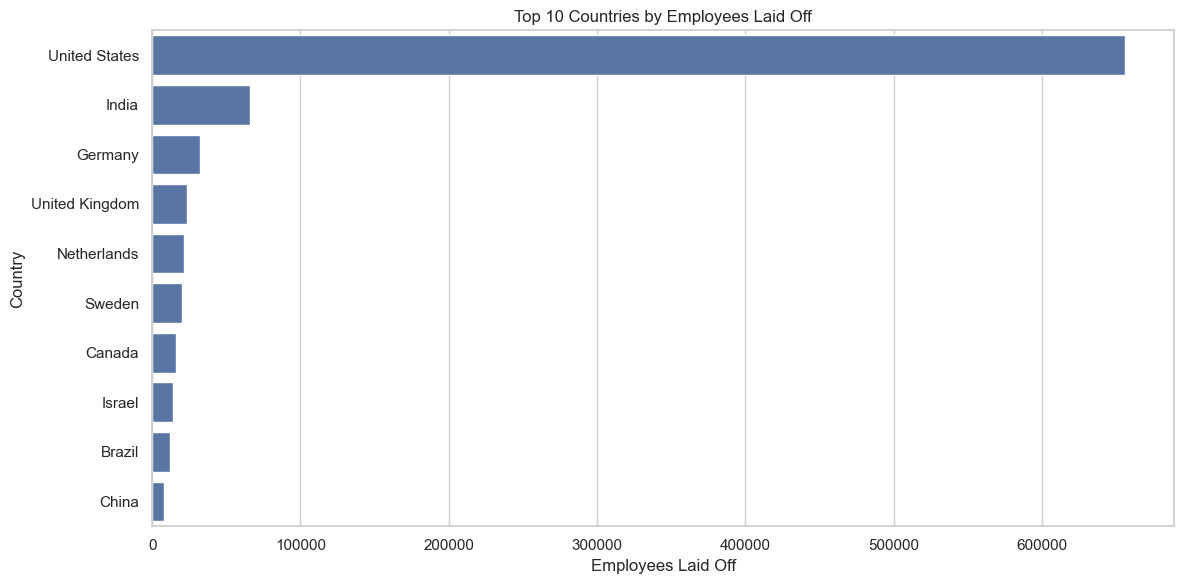

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=country_layoffs,
    x="total_laid_off",
    y="country"
)

plt.title("Top 10 Countries by Employees Laid Off")
plt.xlabel("Employees Laid Off")
plt.ylabel("Country")

plt.tight_layout()
plt.savefig(
    "../outputs/charts/chart5_top_countries.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [14]:
country_events = (
    df.groupby("country")
      .size()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name="Layoff_Events")
)

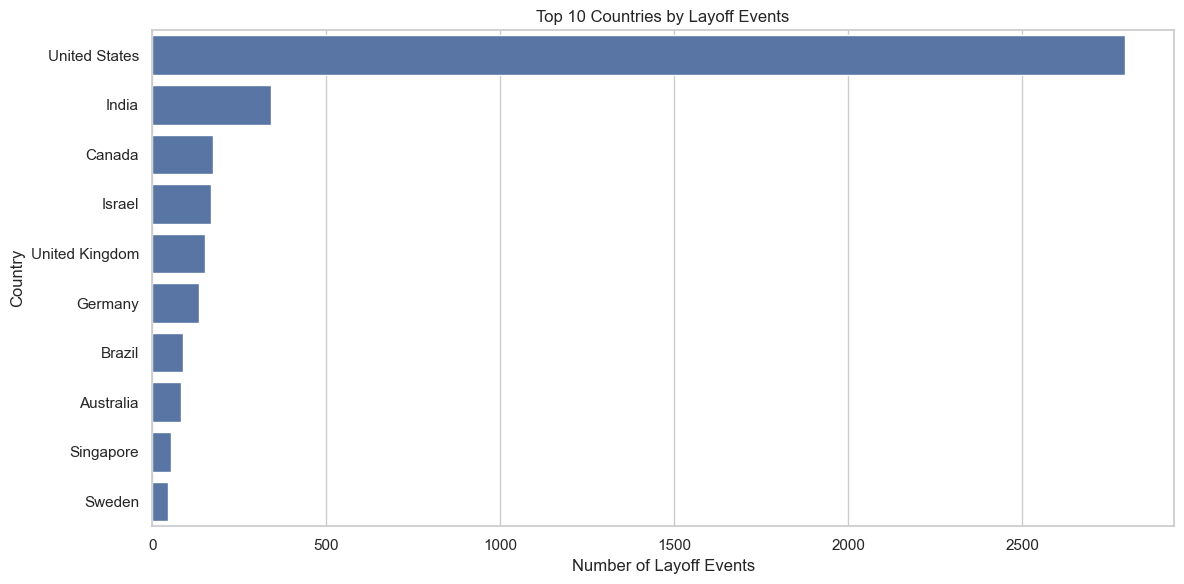

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=country_events,
    x="Layoff_Events",
    y="country"
)

plt.title("Top 10 Countries by Layoff Events")
plt.xlabel("Number of Layoff Events")
plt.ylabel("Country")

plt.tight_layout()
plt.savefig(
    "../outputs/charts/chart6_stage_layoffs.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Question 4
## Which company stages are most vulnerable to layoffs?

In [17]:
stage_layoffs = (
    df.groupby("stage")["total_laid_off"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

In [20]:
stage_avg = (
    df.groupby("stage")["total_laid_off"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

stage_avg

,stage,total_laid_off
0,Post-IPO,776.890667
1,Series J,470.000000
2,Series I,394.375000
3,Subsidiary,376.900000
4,Series H,283.233333
5,Acquired,279.305344
6,Private Equity,261.600000
7,Series G,244.238095
8,Series F,181.423913
9,Unknown,179.608407


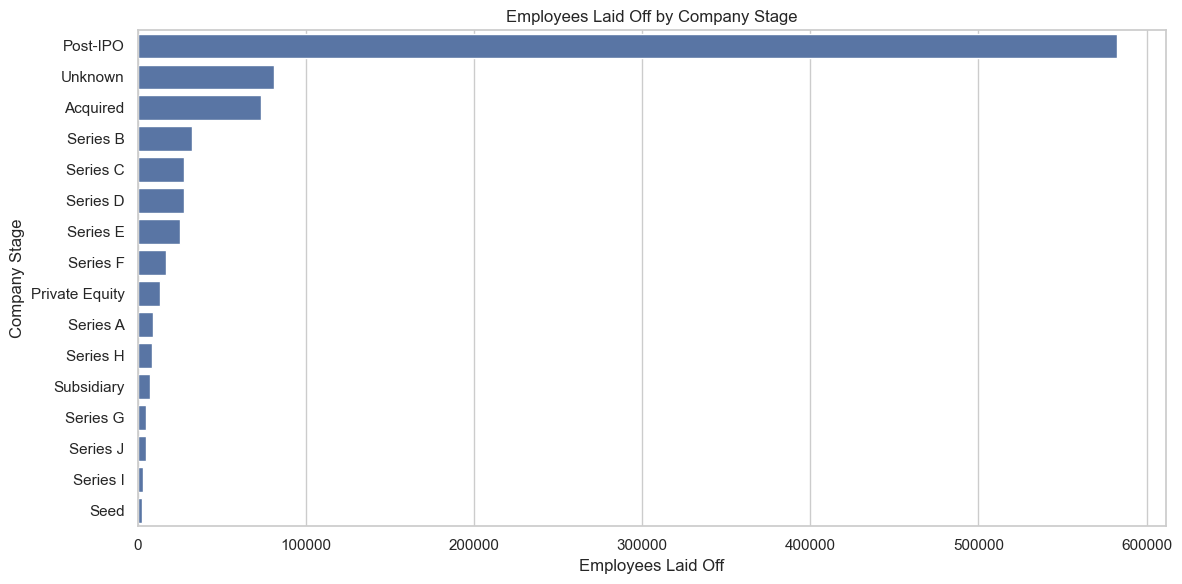

In [21]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=stage_layoffs,
    x="total_laid_off",
    y="stage"
)

plt.title("Employees Laid Off by Company Stage")
plt.xlabel("Employees Laid Off")
plt.ylabel("Company Stage")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/chart7_stage_layoffs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

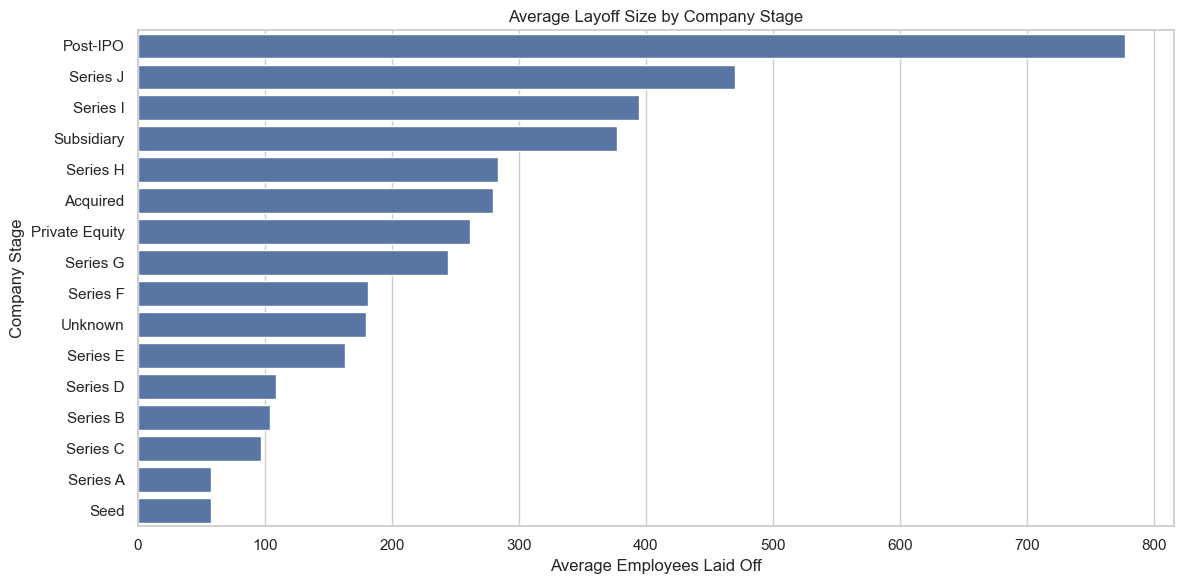

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=stage_avg,
    x="total_laid_off",
    y="stage"
)

plt.title("Average Layoff Size by Company Stage")
plt.xlabel("Average Employees Laid Off")
plt.ylabel("Company Stage")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/chart8_avg_stage_layoff_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insights

- Post-IPO companies experienced the highest number of workforce reductions.
- Acquired and Private Equity-backed companies also recorded substantial layoffs.
- Early-stage startups (Seed and Series A) reported significantly smaller workforce reductions.
- Mature organizations appear more vulnerable to large-scale restructuring efforts than early-stage startups.

# Question 5
## Is there a relationship between funds raised and the magnitude of layoffs?

In [23]:
df["funds_raised"].describe()

count      3916.000000
mean        856.560494
std        4562.857311
min           0.700000
25%          55.000000
50%         175.500000
75%         483.250000
max      121900.000000
Name: funds_raised, dtype: float64

In [24]:
df[["funds_raised", "total_laid_off"]].corr()

,funds_raised,total_laid_off
funds_raised,1.00000,0.11917
total_laid_off,0.11917,1.00000


In [26]:
df["funding_group"] = pd.cut(
    df["funds_raised"],
    bins=[0, 50, 200, 500, 1000, 2000, float("inf")],
    labels=["0-50M", "50-200M", "200-500M", "500M-1B", "1B-2B", "2B+"]
)

In [27]:
funding_summary = (
    df.groupby("funding_group")
      .agg({
          "total_laid_off": "sum",
          "company": "count"
      })
      .reset_index()
)

funding_summary

,funding_group,total_laid_off,company
0,0-50M,168731.0,934
1,50-200M,142238.0,1147
2,200-500M,97389.0,891
3,500M-1B,85149.0,469
4,1B-2B,97578.0,243
5,2B+,166199.0,232


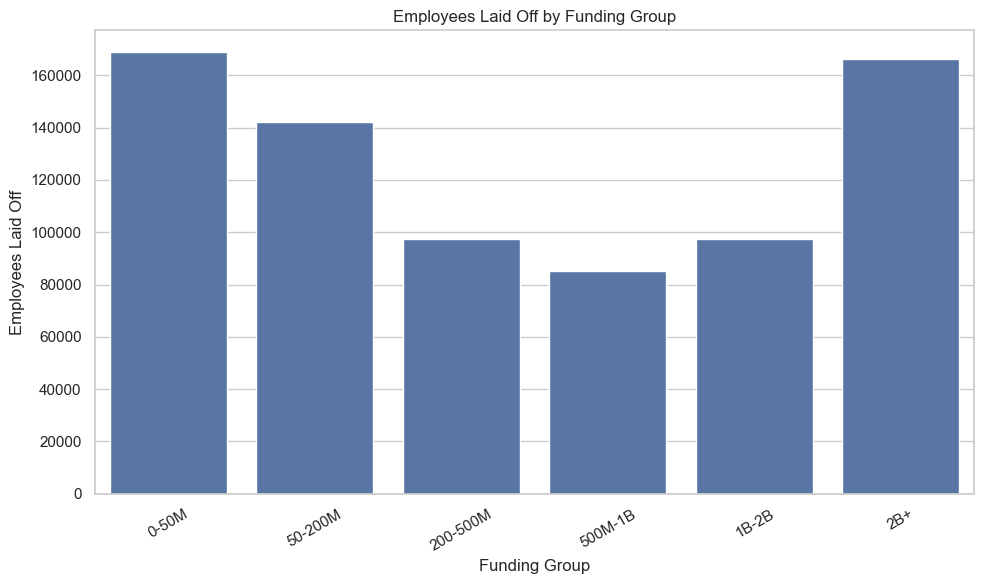

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=funding_summary,
    x="funding_group",
    y="total_laid_off"
)

plt.title("Employees Laid Off by Funding Group")
plt.xlabel("Funding Group")
plt.ylabel("Employees Laid Off")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/chart9_funding_groups.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insights

- Layoffs occurred across all funding categories.
- Companies that raised over $2B collectively accounted for substantial workforce reductions.
- Funding does not guarantee workforce stability.
- The weak correlation between funds raised and layoffs suggests that business strategy, profitability, and market conditions may play a larger role than capital availability.

# Question 6
## Which companies conducted the largest layoffs, and what characteristics do they share?

In [29]:
company_layoffs = (
    df.groupby("company")["total_laid_off"]
      .sum()
      .sort_values(ascending=False)
)

company_layoffs.head(20)

company
Amazon        58124.0
Intel         43115.0
Meta          35700.0
Oracle        31294.0
Microsoft     30055.0
Dell          23650.0
Cisco         18521.0
Salesforce    16525.0
Tesla         14500.0
Google        13697.0
SAP           11000.0
Ericsson      10100.0
Philips       10000.0
PayPal         9428.0
Flink          8100.0
HP             8100.0
Uber           7785.0
Micron         7500.0
Block          5931.0
Getir          5900.0
Name: total_laid_off, dtype: float64

In [30]:
company_summary = (
    df.groupby("company")
      .agg({
          "total_laid_off":"sum",
          "funds_raised":"first",
          "stage":"first",
          "industry":"first",
          "country":"first"
      })
      .sort_values(
          by="total_laid_off",
          ascending=False
      )
)

company_summary.head(20)

,total_laid_off,funds_raised,stage,industry,country
company,,,,,
Amazon,58124.0,8100.0,Post-IPO,Retail,United States
Intel,43115.0,12.0,Post-IPO,Hardware,United States
Meta,35700.0,26000.0,Post-IPO,Consumer,United States
Oracle,31294.0,NaN,Post-IPO,Other,United States
Microsoft,30055.0,1.0,Post-IPO,Other,United States
Dell,23650.0,NaN,Post-IPO,Hardware,United States
Cisco,18521.0,2.0,Post-IPO,Infrastructure,United States
Salesforce,16525.0,65.0,Post-IPO,Sales,United States
Tesla,14500.0,20200.0,Post-IPO,Transportation,United States


In [31]:
top_companies = (
    company_summary
      .head(10)
      .reset_index()
)

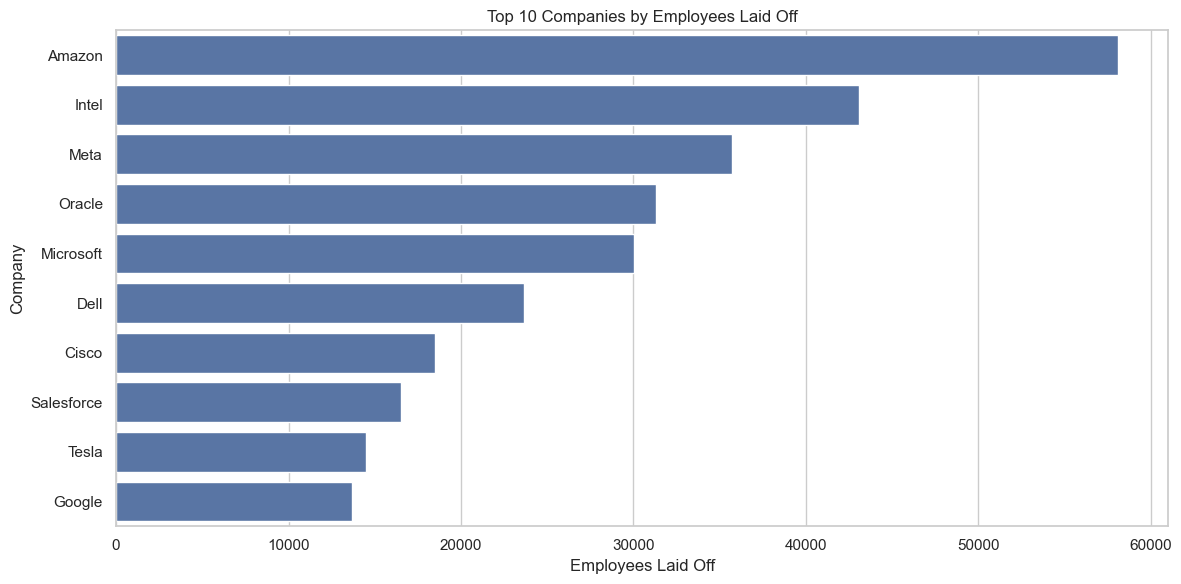

In [32]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_companies,
    x="total_laid_off",
    y="company"
)

plt.title("Top 10 Companies by Employees Laid Off")
plt.xlabel("Employees Laid Off")
plt.ylabel("Company")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/chart10_top_companies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insights

- Amazon recorded the highest number of employees laid off, followed by Intel, Meta, Oracle, and Microsoft.
- Most of the companies with the largest layoffs were Post-IPO organizations.
- The majority of top layoff companies were headquartered in the United States.
- Technology-oriented industries such as Hardware, Consumer, Retail, and Infrastructure were heavily represented.
- High funding levels did not prevent workforce reductions, indicating that strategic restructuring played a larger role than capital availability.

# Overall Conclusion

### Key Takeaways

1. Layoff activity peaked in 2023, making it the most severe year in the dataset.
2. Finance experienced the highest layoff frequency, while Retail and Hardware experienced the largest workforce reductions.
3. The United States dominated global layoff activity, followed by India.
4. Post-IPO companies accounted for the majority of workforce reductions.
5. Funding raised showed only a weak relationship with layoffs.
6. Large technology-focused organizations conducted the biggest workforce reductions.
7. Workforce restructuring was driven primarily by strategic and market factors rather than funding availability alone.